# Hyperparameter optimization with Optuna

Optuna is a framework for organizing and automating parameter searches. This notebook uses it as a concrete implementation of a more durable idea: **hyperparameter optimization is an experiment whose design determines what its result means**.

After working through the notebook, you should be able to:

- distinguish an objective, parameter, trial, study, sampler, and search budget;
- define a small search space and inspect the complete trial history;
- compare stochastic search strategies using equal budgets and repeated runs;
- keep model selection on validation data separate from final evaluation on test data.

The notebook takes roughly 25--30 minutes. It requires NumPy, Matplotlib, and Optuna from the course environment. Its outputs are intentionally omitted: restart the kernel and run all cells so that the narrative and results come from one clean execution.

## The optimization experiment

Optuna uses the following terminology:

| Term | Meaning |
| --- | --- |
| parameter | A value selected by the search, such as a learning rate |
| search space | The allowed values and distributions for all parameters |
| trial | One parameter configuration and its resulting objective value |
| objective | The function that evaluates one trial |
| study | The collection of trials for one optimization task |
| sampler | The strategy that proposes parameter values |
| budget | The limit on trials, elapsed time, or computational resources |

Optuna minimizes or maximizes the value returned by the objective. It does not decide whether that value is scientifically meaningful.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"NumPy {np.__version__}; Optuna {optuna.__version__}")

NumPy 2.5.2; Optuna 4.9.0


## 1. A minimal Optuna study

We start with a deterministic function whose minimum is known. This isolates the mechanics of Optuna from the complications of fitting a model.

In [2]:
def quadratic(x, y):
    return (x - 2.0) ** 2 + (y + 3.0) ** 2


def quadratic_objective(trial):
    x = trial.suggest_float("x", -10.0, 10.0)
    y = trial.suggest_float("y", -10.0, 10.0)
    return quadratic(x, y)

The `Trial` passed to the objective proposes values from the declared search space. A `Study` records every proposed configuration and returned value. We specify TPE explicitly rather than relying on Optuna's current default, and seed it so this sequential demonstration is reproducible.

A fixed number of trials is a **budget**, not a guarantee that the mathematical optimum will be found.

In [3]:
quadratic_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=2025),
)
quadratic_study.optimize(quadratic_objective, n_trials=40)

print(f"Best observed value: {quadratic_study.best_value:.6g}")
print(f"Best observed parameters: {quadratic_study.best_params}")
print("Known optimum: x=2, y=-3, value=0")

Best observed value: 1.02625
Best observed parameters: {'x': 1.1034167295957777, 'y': -3.4715771380493887}
Known optimum: x=2, y=-3, value=0


Do not inspect only the winner. The complete history is needed to diagnose the search and compare strategies.

In [4]:
def trial_record(trial):
    return {
        "number": trial.number,
        "value": trial.value,
        **trial.params,
        "state": trial.state.name,
    }


quadratic_trials = [trial_record(trial) for trial in quadratic_study.trials]
sorted(quadratic_trials, key=lambda record: record["value"])[:5]

[{'number': 31,
  'value': 1.026246557899583,
  'x': 1.1034167295957777,
  'y': -3.4715771380493887,
  'state': 'COMPLETE'},
 {'number': 23,
  'value': 2.024211801609553,
  'x': 0.5777505322469563,
  'y': -3.0376597010840083,
  'state': 'COMPLETE'},
 {'number': 18,
  'value': 2.636132474515999,
  'x': 0.768842970504853,
  'y': -1.9415176698495697,
  'state': 'COMPLETE'},
 {'number': 33,
  'value': 3.7605811197154817,
  'x': 1.3696266132917447,
  'y': -1.166094191882951,
  'state': 'COMPLETE'},
 {'number': 35,
  'value': 4.049780962232426,
  'x': 1.4639167806599174,
  'y': -1.060310400044791,
  'state': 'COMPLETE'}]

## 2. Comparing stochastic search strategies

One successful run is not evidence that one sampler is generally better. We need:

- the same search space and objective;
- the same number of trials per run;
- multiple recorded seeds;
- a performance measure defined before looking at the results.

`RandomSampler` proposes each configuration independently. `TPESampler` starts by gathering observations and then uses the completed trials to propose values that appear more promising. Adaptive sampling can use a limited budget more efficiently, but it can also concentrate on an attractive local region.

The next objective has a broad local basin and a narrow, deeper global basin. It is deliberately small and artificial: its purpose is to make sampler behavior visible.

In [5]:
SEARCH_LOW, SEARCH_HIGH = -10.0, 10.0
GLOBAL_BASIN_THRESHOLD = 1.0


def two_basin_function(x, y, narrow_scale=0.5):
    broad_basin = 7.0 * np.exp(-0.05 * ((x + 3.0) ** 2 + (y - 5.0) ** 2))
    narrow_basin = 10.0 * np.exp(
        -narrow_scale * ((x - 7.0) ** 2 + (y + 3.0) ** 2)
    )
    return 10.0 - broad_basin - narrow_basin


def plot_landscape(ax, points=None, title=None):
    coordinates = np.linspace(SEARCH_LOW, SEARCH_HIGH, 201)
    x_grid, y_grid = np.meshgrid(coordinates, coordinates)
    values = two_basin_function(x_grid, y_grid)
    image = ax.contourf(x_grid, y_grid, values, levels=30, cmap="Greys")
    if points is not None:
        points = np.asarray(points)
        ax.scatter(points[:, 0], points[:, 1], s=18, c="tab:red", edgecolor="white")
    ax.set(xlabel="x", ylabel="y", title=title, aspect="equal")
    return image

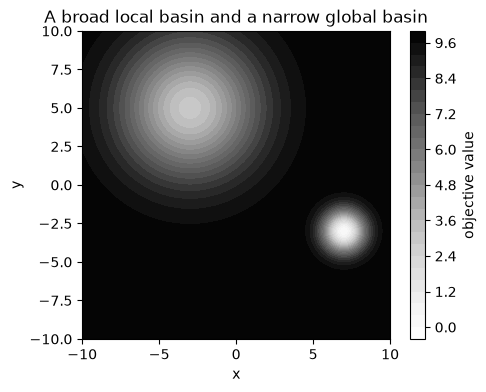

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
image = plot_landscape(ax, title="A broad local basin and a narrow global basin")
fig.colorbar(image, ax=ax, label="objective value")
plt.show()

### Predict before running

With 100 trials, which strategy do you expect to reach the narrow global basin more often: independent random sampling or adaptive TPE sampling? What behavior of the landscape supports your prediction?

Also decide why comparing only the best Random run with the best TPE run would be misleading.

In [7]:
def two_basin_objective(trial):
    x = trial.suggest_float("x", SEARCH_LOW, SEARCH_HIGH)
    y = trial.suggest_float("y", SEARCH_LOW, SEARCH_HIGH)
    return two_basin_function(x, y)


def run_repeated_searches(sampler_factory, seeds, n_trials):
    runs = []
    for seed in seeds:
        study = optuna.create_study(
            direction="minimize", sampler=sampler_factory(seed)
        )
        study.optimize(two_basin_objective, n_trials=n_trials)
        trial_values = np.array([trial.value for trial in study.trials])
        runs.append(
            {
                "seed": seed,
                "best_value": study.best_value,
                "best_x": study.best_params["x"],
                "best_y": study.best_params["y"],
                "best_so_far": np.minimum.accumulate(trial_values),
            }
        )
    return runs

In [8]:
SEEDS = tuple(range(20))
TRIALS_PER_RUN = 100

random_runs = run_repeated_searches(
    lambda seed: optuna.samplers.RandomSampler(seed=seed),
    SEEDS,
    TRIALS_PER_RUN,
)
tpe_runs = run_repeated_searches(
    lambda seed: optuna.samplers.TPESampler(seed=seed),
    SEEDS,
    TRIALS_PER_RUN,
)

In [9]:
def summarize_runs(runs):
    best_values = np.array([run["best_value"] for run in runs])
    hits = best_values < GLOBAL_BASIN_THRESHOLD
    return {
        "runs": len(runs),
        "global-basin hits": int(hits.sum()),
        "hit rate": float(hits.mean()),
        "median best value": float(np.median(best_values)),
        "best observed value": float(best_values.min()),
    }


for name, runs in (("Random", random_runs), ("TPE", tpe_runs)):
    print(name, summarize_runs(runs))

Random {'runs': 20, 'global-basin hits': 1, 'hit rate': 0.05, 'median best value': 3.06324447156503, 'best observed value': 0.1119235414416}
TPE {'runs': 20, 'global-basin hits': 0, 'hit rate': 0.0, 'median best value': 3.010889234960509, 'best observed value': 3.00012710147129}


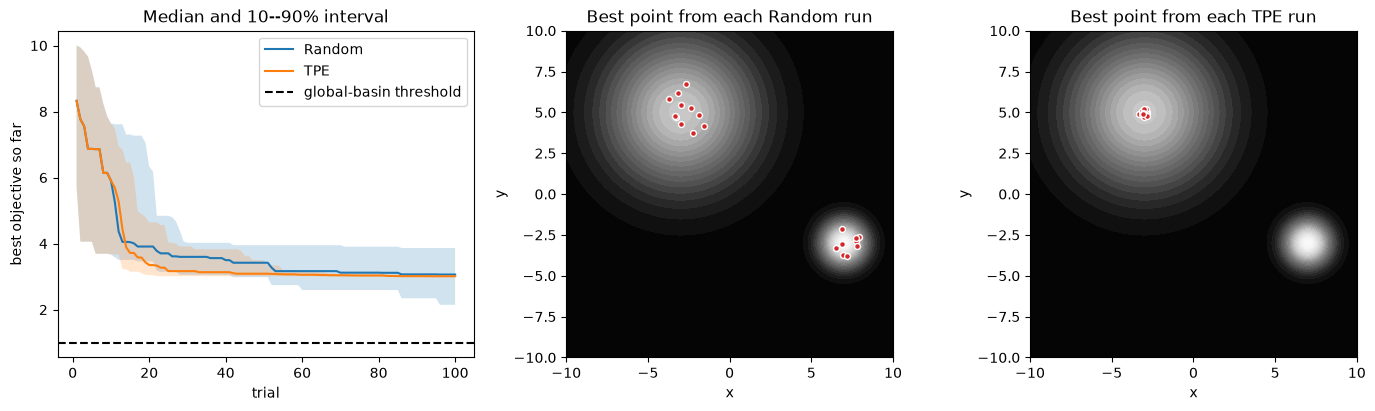

In [10]:
def plot_progress(ax, runs, label):
    histories = np.vstack([run["best_so_far"] for run in runs])
    trial_numbers = np.arange(1, histories.shape[1] + 1)
    lower, median, upper = np.quantile(histories, [0.1, 0.5, 0.9], axis=0)
    ax.plot(trial_numbers, median, label=label)
    ax.fill_between(trial_numbers, lower, upper, alpha=0.2)


fig, axes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)
for name, runs in (("Random", random_runs), ("TPE", tpe_runs)):
    plot_progress(axes[0], runs, name)
axes[0].axhline(GLOBAL_BASIN_THRESHOLD, color="black", linestyle="--", label="global-basin threshold")
axes[0].set(xlabel="trial", ylabel="best objective so far", title="Median and 10--90% interval")
axes[0].legend()

for ax, name, runs in zip(axes[1:], ("Random", "TPE"), (random_runs, tpe_runs)):
    best_points = [(run["best_x"], run["best_y"]) for run in runs]
    plot_landscape(ax, best_points, f"Best point from each {name} run")
plt.show()

### Interpret the evidence

1. Which sampler reached the global basin in more of these runs?
2. Do the median curves and the hit rates support the same conclusion?
3. Would quadrupling the number of trials per run answer the same question as quadrupling the number of repeated runs?

<details>
<summary>Discussion</summary>

The hit rate measures reliability under the stated 100-trial budget; the best single run does not. The median curve describes typical progress, but it can hide rare successes in the narrow basin, so it complements rather than replaces the hit rate. More trials per run investigate performance under a larger search budget. More repeated runs estimate the variability and hit rate at the existing budget more precisely. They answer different questions.

This small experiment is not a general benchmark. TPE uses previous trials to concentrate its search, which can help on many objectives but can also draw attention towards the broad local basin. Sampler performance depends on the landscape, parameter types, dimensionality, budget, and degree of parallelism.
</details>

## 3. From function optimization to hyperparameter optimization

For machine learning, the objective is normally an estimate of performance on **validation data**, not performance on the training data and not performance on the final test data. Every trial influences model selection, so every trial must remain blind to the test set.

We use a small synthetic regression problem so that the model and evidence split remain visible and the example needs no data download. Polynomial degree controls model flexibility; regularization controls how strongly non-constant coefficients are shrunk. Both are hyperparameters because training does not estimate them.

A single train/validation/test split keeps the example short. Cross-validation or repeated validation would usually provide stronger evidence for a real study.

In [11]:
data_rng = np.random.default_rng(2025)
features = np.linspace(-1.0, 1.0, 240)
signal = 0.5 + 1.5 * features - 2.0 * features**2 + np.sin(5.0 * features)
targets = signal + data_rng.normal(loc=0.0, scale=0.3, size=features.size)

indices = data_rng.permutation(features.size)
train_indices = indices[:144]
validation_indices = indices[144:192]
test_indices = indices[192:]

train_features, train_targets = features[train_indices], targets[train_indices]
validation_features = features[validation_indices]
validation_targets = targets[validation_indices]
test_features, test_targets = features[test_indices], targets[test_indices]

print(
    f"train={len(train_targets)}, validation={len(validation_targets)}, "
    f"test={len(test_targets)}"
)

train=144, validation=48, test=48


The objective below varies one structural and one regularizing hyperparameter. Degree is sampled as an integer; the regularization strength spans several orders of magnitude and is therefore sampled on a logarithmic scale.

The fitted model is deterministic for fixed data and hyperparameters. For a stochastic learner, the training seed would also have to be controlled or repeated.

In [12]:
def polynomial_features(features, degree):
    return np.column_stack([features**power for power in range(degree + 1)])


def fit_polynomial(features, targets, degree, regularization):
    design = polynomial_features(features, degree)
    penalty = np.eye(degree + 1)
    penalty[0, 0] = 0.0  # Do not regularize the intercept.
    return np.linalg.solve(
        design.T @ design + regularization * penalty,
        design.T @ targets,
    )


def predict_polynomial(features, coefficients):
    return polynomial_features(features, len(coefficients) - 1) @ coefficients


def root_mean_squared_error(observed, predicted):
    return float(np.sqrt(np.mean((observed - predicted) ** 2)))


def validation_objective(trial):
    degree = trial.suggest_int("degree", 1, 15)
    regularization = trial.suggest_float(
        "regularization", 1.0e-8, 1.0e2, log=True
    )
    coefficients = fit_polynomial(
        train_features, train_targets, degree, regularization
    )
    predictions = predict_polynomial(validation_features, coefficients)
    return root_mean_squared_error(validation_targets, predictions)

In [13]:
model_study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=27182, n_startup_trials=10),
)
model_study.optimize(validation_objective, n_trials=40)

print(f"Best validation RMSE: {model_study.best_value:.3f}")
print(f"Selected hyperparameters: {model_study.best_params}")

Best validation RMSE: 0.374
Selected hyperparameters: {'degree': 5, 'regularization': 4.660416628589115e-05}


In [14]:
model_trials = [trial_record(trial) for trial in model_study.trials]
sorted(model_trials, key=lambda record: record["value"])[:5]

[{'number': 27,
  'value': 0.3740798647846128,
  'degree': 5,
  'regularization': 4.660416628589115e-05,
  'state': 'COMPLETE'},
 {'number': 17,
  'value': 0.37408043705649047,
  'degree': 5,
  'regularization': 3.965750537819765e-05,
  'state': 'COMPLETE'},
 {'number': 31,
  'value': 0.37408299940803746,
  'degree': 5,
  'regularization': 9.019760617729943e-06,
  'state': 'COMPLETE'},
 {'number': 32,
  'value': 0.3740830376869889,
  'degree': 5,
  'regularization': 8.567670844549773e-06,
  'state': 'COMPLETE'},
 {'number': 23,
  'value': 0.3740832297900218,
  'degree': 5,
  'regularization': 6.301286512517622e-06,
  'state': 'COMPLETE'}]

### Final evaluation

Only after selecting a configuration do we combine the training and validation data, fit one final model, and evaluate it once on the test data. The test RMSE estimates the performance of the **entire selection procedure**, not merely the winning fitted model.

In [15]:
final_features = np.concatenate((train_features, validation_features))
final_targets = np.concatenate((train_targets, validation_targets))

final_coefficients = fit_polynomial(
    final_features,
    final_targets,
    model_study.best_params["degree"],
    model_study.best_params["regularization"],
)
test_predictions = predict_polynomial(test_features, final_coefficients)
test_rmse = root_mean_squared_error(test_targets, test_predictions)
print(f"Final test RMSE: {test_rmse:.3f}")

Final test RMSE: 0.309


### Diagnose the experimental design

For each proposal, decide whether it preserves a defensible final evaluation. Explain your decision.

1. Return training RMSE from the Optuna objective because it is less noisy.
2. Return test RMSE from the objective so that Optuna optimizes the quantity ultimately reported.
3. If the final test RMSE is disappointing, enlarge the search space and repeat the study against the same test set.
4. Replace the single validation split with cross-validation while keeping the test set untouched.

<details>
<summary>Solution</summary>

1. No. Training error rewards configurations that fit the observed training data and does not estimate generalization.
2. No. Repeatedly using test performance makes the test set part of model selection, so it no longer supplies independent evidence.
3. No, not if the same test result influences the redesign. The revised procedure needs genuinely external test evidence, or the reported result must explicitly acknowledge that the original test data became development data.
4. Yes. Cross-validation can reduce dependence on one validation split, although it increases computation and does not remove the need for an untouched test set.
</details>

## Takeaways

- Optuna manages trials; it does not make an invalid objective meaningful.
- Define the search space, evidence split, metric, and budget before examining results.
- Compare stochastic strategies over repeated runs with equal budgets, and report typical behavior as well as rare successes.
- Keep the test set outside the optimization loop and use it only after selecting a configuration.
- Record seeds, software versions, trial histories, failures, and resource budgets. Exact reproducibility becomes harder with stochastic objectives or parallel and distributed execution.

The [parameterized heat-equation PINN optimization notebook](parameterized_heat_equation_optimization.ipynb) applies these principles to a more realistic and more expensive case.

Further reading:

- [Optuna: first optimization](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/001_first.html)
- [Optuna: samplers and pruning](https://optuna.readthedocs.io/en/stable/tutorial/10_key_features/003_efficient_optimization_algorithms.html)
- [Optuna FAQ: reproducibility](https://optuna.readthedocs.io/en/stable/faq.html#how-can-i-obtain-reproducible-optimization-results)